# Data Workflow & Acquisition
# Hospital Appointment No-Show Prediction

## 0. Setup

In [2]:
import os
import sys
import platform
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('pandas:', pd.__version__)

Python: 3.13.7
Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.42
pandas: 3.0.1


### 0.1. Project Structure

In [8]:
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "no_show_predict"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CONFIGS = PROJECT_ROOT / "configs"

PROJECT_ROOT

PosixPath('/media/irseora/external/Repos/Data-Science/no_show_predict')

## 1. Load & Inspect the Dataset

### 1.1. Basic Read

In [9]:
raw_data_path = DATA_RAW / "appointments_raw.csv"
df_raw = pd.read_csv(raw_data_path)

print(df_raw.shape)
df_raw.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### 1.2. Inspect Schema

In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


### 1.3. Inspect Quality

In [11]:
df_raw.isna().sum().sort_values(ascending=False)

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [12]:
df_raw.duplicated().sum()

np.int64(0)

### 1.4. Parsing

In [13]:
def parse_data(df_raw):
    df = df_raw.copy()
    
    # Rename for consistency
    df = df.rename(columns={
        "Hipertension": "Hypertension",
        "Handcap": "Handicap",
        "SMS_received": "SMSReceived",
        "No-show": "NoShow"
    })

    # IDs
    df["PatientId"] = df["PatientId"].astype(str)
    df["AppointmentID"] = df["AppointmentID"].astype(str)

    # Dates
    df["ScheduledDay"] = pd.to_datetime(
        df["ScheduledDay"], errors = "coerce",
    )
    df["AppointmentDay"] = pd.to_datetime(
        df["AppointmentDay"], errors = "coerce",
    )

    # Categoricals
    df["Gender"] = df["Gender"].astype("category")
    df["Neighbourhood"] = df["Neighbourhood"].astype("category")

    # Binary -> bool
    binary_cols = [
        "Scholarship", "Hypertension", "Diabetes",
        "Alcoholism", "Handicap", "SMSReceived"
    ]
    for col in binary_cols:
        df[col] = df[col].astype(bool)

    # Target
    df["NoShow"] = df["NoShow"].map({ 
        "Yes": True,
        "No": False
    })
    
    # Derived column: Waiting time in days
    df["WaitingDays"] = (
        df["ScheduledDay"] - df["AppointmentDay"]
    ).dt.days

    return df

df_interim = parse_data(df_raw)
df_interim.info()

# Saving
interim_path = DATA_INTERIM / "appointments_interim.csv"
df_interim.to_csv(interim_path, index = False)

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  str                
 1   AppointmentID   110527 non-null  str                
 2   Gender          110527 non-null  category           
 3   ScheduledDay    110527 non-null  datetime64[us, UTC]
 4   AppointmentDay  110527 non-null  datetime64[us, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  category           
 7   Scholarship     110527 non-null  bool               
 8   Hypertension    110527 non-null  bool               
 9   Diabetes        110527 non-null  bool               
 10  Alcoholism      110527 non-null  bool               
 11  Handicap        110527 non-null  bool               
 12  SMSReceived     110527 non-null  bool               
 13  NoShow          110527 no

### 1.5. Validation

In [14]:
def validate_data(df_interim):
    df = df_interim.copy()

    # Unrealistic ages
    median_age = df["Age"].median()

    neg_age_mask = df["Age"] < 0
    high_age_mask = df["Age"] > 120

    nr_neg_age = neg_age_mask.sum()
    nr_high_age = high_age_mask.sum()

    df.loc[neg_age_mask, "Age"] = median_age
    df.loc[high_age_mask, "Age"] = median_age

    # Wrong date order
    wrong_date_mask = df["ScheduledDay"] < df["AppointmentDay"]
    nr_wrong_dates = wrong_date_mask.sum()
    
    df.loc[wrong_date_mask, ["AppointmentDay", "ScheduledDay"]] = \
        df.loc[wrong_date_mask, ["ScheduledDay", "AppointmentDay"]].values
    df["WaitingDays"] = (
        df["ScheduledDay"] - df["AppointmentDay"]
    ).dt.days

    # Report
    print(f"Negative ages fixed: {nr_neg_age}")
    print(f"Unrealistic ages fixed: {nr_high_age}")
    print(f"Swapped incorrect dates: {nr_wrong_dates}")

    return df

df_processed = validate_data(df_interim)
df_processed.info()

# Saving
processed_path = DATA_PROCESSED / "appointments_processed.csv"
df_processed.to_csv(processed_path, index = False)

Negative ages fixed: 1
Unrealistic ages fixed: 0
Swapped incorrect dates: 71959
<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  str                
 1   AppointmentID   110527 non-null  str                
 2   Gender          110527 non-null  category           
 3   ScheduledDay    110527 non-null  datetime64[us, UTC]
 4   AppointmentDay  110527 non-null  datetime64[us, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  category           
 7   Scholarship     110527 non-null  bool               
 8   Hypertension    110527 non-null  bool               
 9   Diabetes        110527 non-null  bool               
 10  Alcoholism      110527 non-null  bool               
 11  Handicap        110527 non-null  bool               
 12  SMS

## 2. Univariate Analysis
**Chosen Variable**: `WaitingDays`

### 2.1. Summary

In [15]:
df = df_processed.copy()
waiting = df["WaitingDays"]

count = waiting.count()
min_val = waiting.min()
max_val = waiting.max()
mean_val = waiting.mean()
median_val = waiting.median()
std_val = waiting.std()

q1 = waiting.quantile(0.25)
q3 = waiting.quantile(0.75)
iqr = q3 - q1

print("WaitingDays Summary")
print(f"Count: {count}")
print(f"Min: {min_val} \t \t Max: {max_val}")
print(f"Mean: {mean_val:.2f} \t Median: {median_val}")
print(f"Standard Deviation: {std_val:.2f}")
print(f"IQR: {iqr} (Q1={q1}, Q3={q3})")

WaitingDays Summary
Count: 110527
Min: 0 	 	 Max: 178
Mean: 9.53 	 Median: 3.0
Standard Deviation: 15.03
IQR: 14.0 (Q1=0.0, Q3=14.0)


### 2.2. Visualization

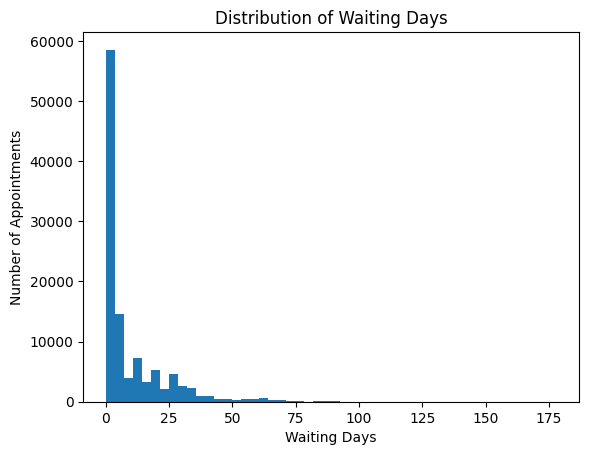

In [16]:
plt.hist(df["WaitingDays"], bins = 50)

plt.title("Distribution of Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Number of Appointments")

plt.show()

### 2.3. Conclusion

The typical waiting time is short, an average patient waits about 3 days to be seen.
50% of patients wait 0 to 14 days, while 25% of appointments happen the same day.